In [1]:
import pandas as pd
stroke = pd.read_csv('healthcare-dataset-stroke-data.csv')
stroke

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [2]:
stroke.shape

(5110, 12)

In [4]:
stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
stroke.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
stroke['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [7]:
stroke['stroke'].value_counts(normalize=True)

stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64

In [8]:
stroke['gender'].value_counts()
stroke['ever_married'].value_counts()
stroke['work_type'].value_counts()
stroke['Residence_type'].value_counts()
stroke['smoking_status'].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [9]:
stroke.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [10]:
stroke.groupby('stroke')[['age', 'avg_glucose_level']].mean()

,age,avg_glucose_level
stroke,,
0,41.971545,104.795513
1,67.728193,132.544739


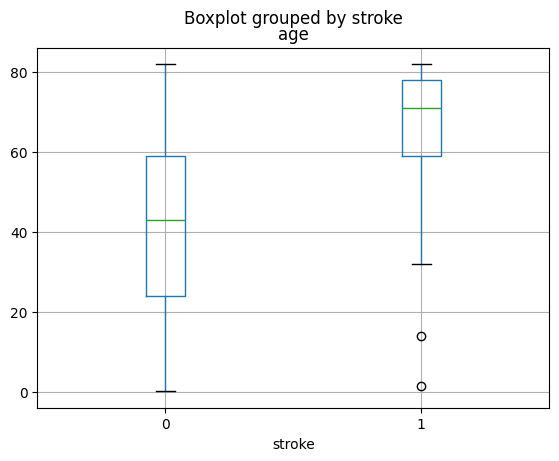

In [11]:
import matplotlib.pyplot as plt

stroke.boxplot(column='age', by='stroke')
plt.show()

In [12]:
stroke[stroke['stroke'] == 1].sort_values('age')[['age', 'stroke']]

,age,stroke
162,1.32,1
245,14.00,1
182,32.00,1
118,38.00,1
133,38.00,1
...,...,...
56,82.00,1
187,82.00,1
140,82.00,1
128,82.00,1


In [13]:
stroke[stroke['age'] < 18][['age', 'gender', 'hypertension',
                     'heart_disease', 'avg_glucose_level',
                     'bmi', 'smoking_status', 'stroke']]

,age,gender,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke
162,1.32,Female,0,0,70.37,NaN,Unknown,1
245,14.00,Female,0,0,57.93,30.9,Unknown,1
249,3.00,Male,0,0,95.12,18.0,Unknown,0
251,8.00,Female,0,0,110.89,17.6,Unknown,0
253,14.00,Male,0,0,161.28,19.1,Unknown,0
...,...,...,...,...,...,...,...,...
5089,0.72,Female,0,0,62.13,16.8,Unknown,0
5094,13.00,Male,0,0,82.38,24.3,Unknown,0
5095,1.08,Male,0,0,79.15,17.4,Unknown,0
5098,9.00,Male,0,0,71.88,17.5,Unknown,0


In [15]:
stroke[(stroke['age'] < 18) & (stroke['stroke'] == 1)]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
162,69768,Female,1.32,0,0,No,children,Urban,70.37,NaN,Unknown,1
245,49669,Female,14.00,0,0,No,children,Rural,57.93,30.9,Unknown,1


In [16]:
stroke[(stroke['age'] < 18) & (stroke['stroke'] == 1)].shape

(2, 12)

In [17]:
stroke[stroke['age'] < 18].shape

(856, 12)

In [20]:
bins = [0, 18, 30, 45, 60, 75, 100]

labels = ['<18', '18-29', '30-44', '45-59', '60-74', '75+']

stroke['age_group'] = pd.cut(stroke['age'], bins=bins, labels=labels)

In [21]:
pd.crosstab(stroke['age_group'], stroke['stroke'])

stroke,0,1
age_group,,
<18,914,2
18-29,654,0
30-44,1037,11
45-59,1129,59
60-74,758,81
75+,369,96


In [23]:
pd.crosstab(
    stroke['age_group'],
    stroke['stroke'],
    normalize='index'
) * 100

stroke,0,1
age_group,,
<18,99.781659,0.218341
18-29,100.000000,0.000000
30-44,98.950382,1.049618
45-59,95.033670,4.966330
60-74,90.345650,9.654350
75+,79.354839,20.645161


In [25]:
bins = [0, 18, 30, 45, 60, 75, 100]
labels = ['<18', '18-29', '30-44', '45-59', '60-74', '75+']

stroke['age_group'] = pd.cut(
    stroke['age'],
    bins=bins,
    labels=labels
)

pd.crosstab(stroke['age_group'], stroke['stroke'])

stroke,0,1
age_group,,
<18,914,2
18-29,654,0
30-44,1037,11
45-59,1129,59
60-74,758,81
75+,369,96


In [26]:
pd.crosstab(
    stroke['age_group'],
    stroke['stroke'],
    normalize='index'
) * 100

stroke,0,1
age_group,,
<18,99.781659,0.218341
18-29,100.000000,0.000000
30-44,98.950382,1.049618
45-59,95.033670,4.966330
60-74,90.345650,9.654350
75+,79.354839,20.645161


In [28]:
stroke.duplicated().sum()

np.int64(0)

In [29]:
stroke.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
age_group              0
dtype: int64

In [30]:
stroke['bmi'].isnull().mean() * 100

np.float64(3.9334637964774952)

In [32]:
stroke['bmi'].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

In [34]:
stroke['bmi'].median()

np.float64(28.1)

In [35]:
stroke['bmi'] = stroke['bmi'].fillna(stroke['bmi'].median())

In [37]:
stroke['bmi'].isnull().sum()

np.int64(0)

In [38]:
stroke.duplicated().sum()

np.int64(0)

In [39]:
stroke.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
age_group            0
dtype: int64

In [41]:
stroke.select_dtypes(include='object').nunique()

gender            3
ever_married      2
work_type         5
Residence_type    2
smoking_status    4
dtype: int64

In [42]:
for col in stroke.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(stroke[col].unique())


gender:
['Male' 'Female' 'Other']

ever_married:
['Yes' 'No']

work_type:
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Residence_type:
['Urban' 'Rural']

smoking_status:
['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [43]:
stroke.to_csv('stroke_cleaned.csv', index=False)

In [44]:
df = pd.read_csv('stroke_cleaned.csv')
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,age_group
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,60-74
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,60-74
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,75+
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,45-59
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,75+
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,28.1,never smoked,0,75+
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0,75+
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0,30-44
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0,45-59


In [45]:
print(df.shape)
print(df.isnull().sum())

(5110, 13)
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
age_group            0
dtype: int64


In [62]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [67]:
X = df.drop('stroke', axis = 1)
y = df['stroke']
X = pd.get_dummies(X,columns = ['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status', 'age_group'],drop_first = True)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = 42,
    stratify = y,
)

In [68]:
model = RandomForestClassifier(random_state = 42)

In [69]:
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [70]:
prediction = model.predict(X_test)

In [72]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



[[971   1]
 [ 50   0]]


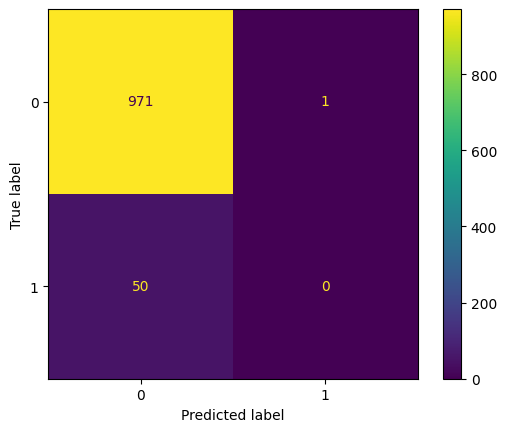

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, prediction)
print(cm)

ConfusionMatrixDisplay.from_predictions(y_test, prediction)

In [76]:
print(y_train.value_counts())
print(y_test.value_counts())

stroke
0    3889
1     199
Name: count, dtype: int64
stroke
0    972
1     50
Name: count, dtype: int64


In [77]:
print(y_train.value_counts(normalize=True))

stroke
0    0.951321
1    0.048679
Name: proportion, dtype: float64


In [78]:
model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

In [79]:
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



[[972   0]
 [ 49   1]]


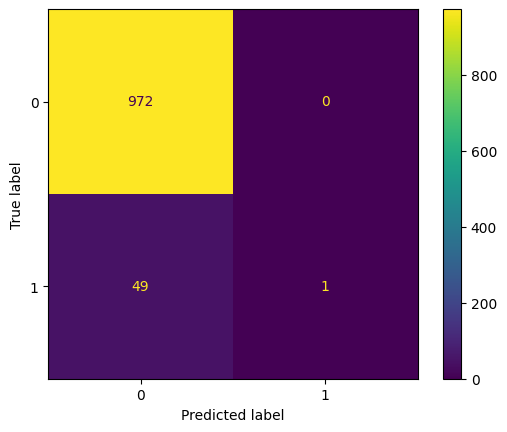

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions)

print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

In [81]:
probabilities = model.predict_proba(X_test)[:, 1]

In [82]:
print(probabilities[:20])

[0.01 0.   0.   0.   0.03 0.   0.   0.   0.   0.   0.15 0.   0.23 0.
 0.   0.   0.   0.   0.   0.02]


In [83]:
threshold = 0.2

predictions_02 = (probabilities >= threshold).astype(int)

print(classification_report(y_test, predictions_02))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95       972
           1       0.21      0.26      0.23        50

    accuracy                           0.91      1022
   macro avg       0.58      0.60      0.59      1022
weighted avg       0.92      0.91      0.92      1022



In [84]:
threshold = 0.1

predictions_01 = (probabilities >= threshold).astype(int)

print(classification_report(y_test, predictions_01))

              precision    recall  f1-score   support

           0       0.97      0.86      0.91       972
           1       0.17      0.56      0.26        50

    accuracy                           0.84      1022
   macro avg       0.57      0.71      0.59      1022
weighted avg       0.93      0.84      0.88      1022



In [85]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

for threshold in thresholds:
    predictions = (probabilities >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.05 | Precision: 0.12 | Recall: 0.76 | F1: 0.21
Threshold: 0.10 | Precision: 0.17 | Recall: 0.56 | F1: 0.26
Threshold: 0.15 | Precision: 0.19 | Recall: 0.40 | F1: 0.26
Threshold: 0.20 | Precision: 0.21 | Recall: 0.26 | F1: 0.23
Threshold: 0.25 | Precision: 0.18 | Recall: 0.12 | F1: 0.14
Threshold: 0.30 | Precision: 0.20 | Recall: 0.08 | F1: 0.11
Threshold: 0.40 | Precision: 0.25 | Recall: 0.02 | F1: 0.04
Threshold: 0.50 | Precision: 1.00 | Recall: 0.02 | F1: 0.04


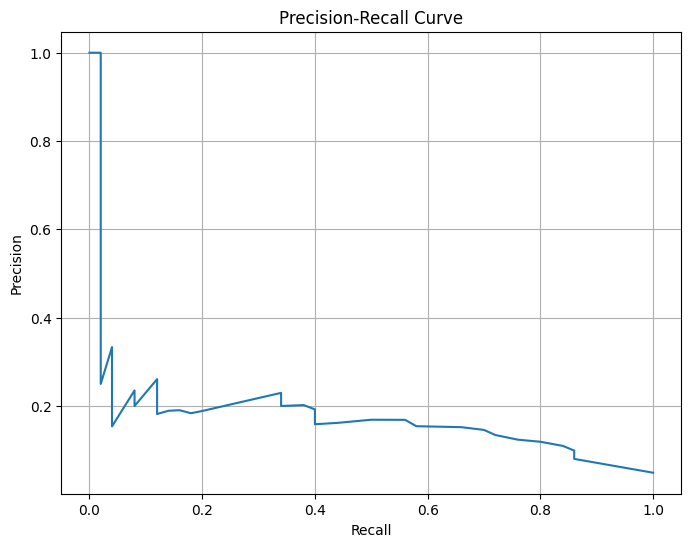

In [86]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    probabilities
)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()

plt.show()

In [87]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_test, probabilities)

print(f"Average Precision: {ap:.3f}")

Average Precision: 0.178


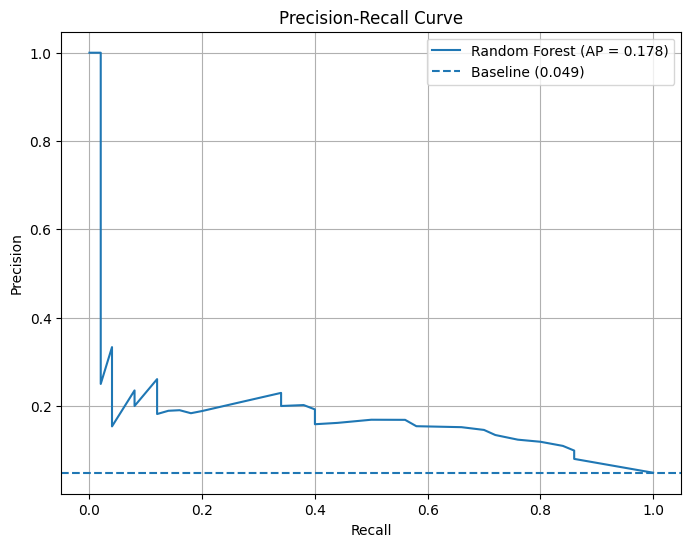

In [88]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    probabilities
)

ap = average_precision_score(y_test, probabilities)

baseline = y_test.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"Random Forest (AP = {ap:.3f})"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline ({baseline:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()

plt.show()